## 1. Ответы на вопросы

### 1.1. Аналитическое решение задачи регрессии в векторной форме

Для линейной регрессии аналитическое решение в векторной форме получается из минимизации среднеквадратичной ошибки.

Пусть:
- $X \in \mathbb{R}^{n \times d}$ — матрица признаков
- $y \in \mathbb{R}^{n}$ — вектор целевых значений
- $w \in \mathbb{R}^{d}$ — вектор весов модели

Тогда линейная модель записывается как:

$$
\hat{y} = Xw
$$

Задача линейной регрессии состоит в минимизации суммы квадратов ошибок:

$$
L(w) = \|Xw - y\|_2^2
$$

Раскроем функцию потерь в векторной форме:

$$
L(w) = (Xw - y)^T (Xw - y)
$$

Найдем градиент функции потерь по вектору весов $w$:

$$
\nabla_w L(w) = 2X^T(Xw - y)
$$

Для нахождения минимума приравниваем градиент к нулю:

$$
2X^T(Xw - y) = 0
$$

Тогда получаем нормальные уравнения:

$$
X^T X w = X^T y
$$

Если матрица $X^T X$ обратима, то аналитическое решение имеет вид:

$$
w = (X^T X)^{-1} X^T y
$$

Это и есть аналитическое решение задачи линейной регрессии в векторной форме.

## Учет свободного члена

Если модель содержит свободный член $b$, то удобно добавить к матрице признаков столбец из единиц:

$$
\tilde{X} = [\mathbf{1}, X]
$$

Тогда вектор параметров будет:

$$
\theta =
\begin{pmatrix}
b \\
w
\end{pmatrix}
$$

А модель примет вид:

$$
\hat{y} = \tilde{X}\theta
$$

Тогда аналитическое решение записывается так:

$$
\theta = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T y
$$

## Случай необратимости матрицы

Если матрица $X^T X$ необратима, например при сильной корреляции признаков или когда число признаков больше числа объектов, то используют псевдообратную матрицу Мура-Пенроуза:

$$
w = X^+ y
$$

## Вывод

Таким образом, аналитическое решение линейной регрессии получается через минимизацию квадратичной функции потерь. В результате получаем формулу нормальных уравнений, из которой находится оптимальный вектор весов:

$$
w = (X^T X)^{-1} X^T y
$$

или, в общем случае,

$$
w = X^+ y
$$

### 1.2. Изменение при добавлении L1 и L2 регуляризации


Для L2-регуляризации задача принимает вид:

$$
L(w) = \|Xw - y\|_2^2 + \lambda \|w\|_2^2
$$

и аналитическое решение становится:

$$
w = (X^T X + \lambda I)^{-1} X^T y
$$

Для L1-регуляризации задача принимает вид:

$$
L(w) = \|Xw - y\|_2^2 + \lambda \|w\|_1
$$

но простого аналитического решения уже нет, поэтому используются численные методы.   
L1 чаще приводит к разреженному решению, а L2 делает модель более устойчивой.

### 1.3. Причины равенства некотрых весов при L1 регуляризации

Главная особенность L1-регуляризации состоит в том, что она штрафует веса линейно:

$$
|w_j|
$$

В отличие от L2-регуляризации, где используется квадрат веса:

$$
w_j^2
$$

Геометрически это приводит к тому, что оптимум при L1-регуляризации часто достигается на осях координат, то есть в точках, где часть коэффициентов точно равна нулю:

$$
w_j = 0
$$

Это означает, что модель полностью исключает некоторые признаки из уравнения.  

**! ВАЖНО**

L1-регуляризация часто используется для отбора признаков, потому что добавляет штраф за сумму абсолютных значений весов и тем самым приводит к разреженному решению. В ходе обучения модель стремится занулить коэффициенты у менее полезных признаков. Поэтому после обучения многие веса оказываются равны нулю, а в модели остаются только наиболее значимые признаки.  
L2-регулярищация делает модель более устойчивой, но не выполняет явный отбор признаков.

### 1.4. Использование линейных моделей для обучения нелинейных зависимостей.

Линейная регрессия, Ridge, Lasso и ElasticNet называются линейными моделями, потому что они линейны по параметрам. Чтобы сделать возможным обучение нелинейных зависимостей мы преобразовываем исходные признаки в новые, нелинейные признаки.

## Общая идея

Пусть исходная модель имеет вид:

$$
\hat{y} = w^T x + b
$$

Если заменить исходный вектор признаков $x$ на некоторую нелинейную функцию признаков $\phi(x)$, то модель примет вид:

$$
\hat{y} = w^T \phi(x) + b
$$

Тогда модель остается линейной по коэффициентам $w$, но становится нелинейной по исходным признакам $x$.

Именно так линейные модели можно использовать для описания нелинейных зависимостей.

## Примеры нелинейных преобразований признаков

### Полиномиальные признаки

Самый распространенный способ — добавить полиномиальные признаки. Например, если исходный признак один:

$$
x
$$

то можно построить новые признаки:

$$
x,\; x^2,\; x^3,\; \dots,\; x^k
$$

Тогда модель будет выглядеть так:

$$
\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \dots + w_k x^k
$$

Такая модель уже может аппроксимировать криволинейные зависимости.

### Попарные произведения признаков

Если признаков несколько, можно добавлять их взаимодействия. Например, для двух признаков $x_1$ и $x_2$:

$$
x_1,\; x_2,\; x_1^2,\; x_2^2,\; x_1 x_2
$$

Тогда модель сможет учитывать не только отдельное влияние каждого признака, но и их совместное влияние.

### Другие нелинейные преобразования

Также можно использовать другие функции от признаков:

$$
\log(x), \quad \sqrt{x}, \quad \sin(x), \quad e^x
$$

Если такие преобразования имеют смысл для предметной области, они тоже позволяют линейной модели описывать нелинейное поведение.

## Почему модель все еще считается линейной

После преобразования признаков модель имеет вид:

$$
\hat{y} = w_1 \phi_1(x) + w_2 \phi_2(x) + \dots + w_m \phi_m(x) + b
$$

Хотя функции $\phi_i(x)$ могут быть нелинейными, сама модель остается линейной по коэффициентам $w_i$. Поэтому к ней можно применять те же методы:
- Linear Regression
- Ridge
- Lasso
- ElasticNet

Меняется только пространство признаков, а не принцип работы алгоритма.

## Практический смысл

Таким образом, чтобы линейная модель обучала нелинейные зависимости, нужно:

1. взять исходные признаки
2. построить на их основе новые нелинейные признаки
3. обучить обычную линейную модель на расширенном наборе признаков

То есть вместо изменения модели мы изменяем представление данных.

## Связь с переобучением

При добавлении большого количества нелинейных признаков модель становится более гибкой и может лучше подстраиваться под данные. Но при этом возрастает риск переобучения.

Именно поэтому в таких задачах особенно полезны Ridge, Lasso и ElasticNet. Они позволяют контролировать сложность.

## 2. Введение

Preprocessing — это предобработка данных перед обучением модели машинного обучения. На этом этапе исходные данные подготавливаются так, чтобы алгоритм мог корректно с ними работать и получать более качественный результат.

Цели:  
- очистить данные от ошибок и пропусков
- привести признаки к удобному формату
- выделить полезную информацию
- подготовить данные к обучению модели

1. Очистка данных

- удаление дубликатов
- исправление ошибки в значениях
- обрабатка пропущенных значений
- приведение данных к корректным типам

2. Преобразование категориальных признаков  
    Некотрые модели обучения не умеют работать со строками на прямую, поэтому делают:
- `"low"`, `"medium"`, `"high"` можно заменить на числа
- можно использовать one-hot encoding

3. Маштабирование и нормализация  
    Модели чувствительны к масштабу признаков, делаем:
- `MinMaxScaler`
- `StandardScaler`

4. Создание новых признаков    
    Из исходных данных можно создать более полезные признаки:
- из даты можно получить месяц, день недели, час
- из текстового списка признаков квартиры можно получить набор бинарных признаков
- можно добавить полиномиальные признаки

5. Удаление лишних признаков

6. Разделение данных  
    Подготовка обучающей и тестовой выборок

In [1]:
import pandas as pd

In [2]:
# Импорт данных
train_df = pd.read_json("../data/train.json")
test_df = pd.read_json("../data/test.json")
#train_df.head()

In [3]:
# Предобработка "Interest Level"

print(f"Заголовки: \n{train_df.columns}\n")
print(f"Interest_level первые 5 значений: \n{train_df["interest_level"].head()}\n")
print(f"Количество значений: \n{train_df["interest_level"].value_counts()}\n")

# Кодируем Interest level
interest_level_map = {
    "low": 0,
    "medium": 1,
    "high": 2
}

print(f"Кодируем значения в числа")
train_df["interest_level"] = train_df["interest_level"].map(interest_level_map)
print(f"Interest_level первые 5 значений: \n{train_df["interest_level"].head()}\n")
print(f"Если = 0, то кодирование успешно: \n{train_df["interest_level"].isna().sum()}\n")
print(f"Количество значений: \n{train_df["interest_level"].value_counts().sort_index()}\n")

Заголовки: 
Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='str')

Interest_level первые 5 значений: 
4     medium
6        low
9     medium
10    medium
15       low
Name: interest_level, dtype: str

Количество значений: 
interest_level
low       34284
medium    11229
high       3839
Name: count, dtype: int64

Кодируем значения в числа
Interest_level первые 5 значений: 
4     1
6     0
9     1
10    1
15    0
Name: interest_level, dtype: int64

Если = 0, то кодирование успешно: 
0

Количество значений: 
interest_level
0    34284
1    11229
2     3839
Name: count, dtype: int64



## 3. Вводный анализ данных

In [4]:
# 3.1
train_df["features"].head() 


# 3.2
# Очистка от неиспользуемых символов
def clean_features(feature_list):
    cleaned = []

    for feature in feature_list:
        feature = feature.replace("[","")
        feature = feature.replace("]","")
        feature = feature.replace("'","")
        feature = feature.replace('"',"")
        feature = feature.replace(" ","")
        cleaned.append(feature)
    
    return cleaned


train_df["features"] = train_df["features"].apply(clean_features)
test_df["features"] = test_df["features"].apply(clean_features)

print(train_df["features"].head())

#3.3
# Собираем результат в один большой список
all_features = []

for _, row in train_df.iterrows(): # .iterrows() - метод pandas, проходит по очереди по всем строкам dataframe
    for feature in row["features"]:
        all_features.append(feature)

print(f"\nall_features:\n{all_features[:20]}\n")

#3.4
print(f"Количество значений в списке:\n{len(all_features)}")
print(f"Количество уникальных значений в списке:\n{len(set(all_features))}\n")

4     [DiningRoom, Pre-War, LaundryinBuilding, Dishw...
6     [Doorman, Elevator, LaundryinBuilding, Dishwas...
9     [Doorman, Elevator, LaundryinBuilding, Laundry...
10                                                   []
15    [Doorman, Elevator, FitnessCenter, LaundryinBu...
Name: features, dtype: object

all_features:
['DiningRoom', 'Pre-War', 'LaundryinBuilding', 'Dishwasher', 'HardwoodFloors', 'DogsAllowed', 'CatsAllowed', 'Doorman', 'Elevator', 'LaundryinBuilding', 'Dishwasher', 'HardwoodFloors', 'NoFee', 'Doorman', 'Elevator', 'LaundryinBuilding', 'LaundryinUnit', 'Dishwasher', 'HardwoodFloors', 'Doorman']

Количество значений в списке:
267906
Количество уникальных значений в списке:
1546



In [5]:
#3.5 Библиотека collections
# Используется для удобного подсчета вхождений элементов в список и заключениях их в словарь
from collections import Counter

feature_counter = Counter(all_features)
print(feature_counter)

#3.6-3.7 Топ-20 признаков 
top_20_feature = feature_counter.most_common(20) #.most_common() - метод collection, возвращает 20 встречаемых элементов списка
print(f"\nTop 20 популярных признаков (используем Collections):")
for feature, count in top_20_feature:
    print(f"{feature}: {count}")

Counter({'Elevator': 25915, 'CatsAllowed': 23540, 'HardwoodFloors': 23527, 'DogsAllowed': 22035, 'Doorman': 20898, 'Dishwasher': 20426, 'NoFee': 18062, 'LaundryinBuilding': 16344, 'FitnessCenter': 13252, 'Pre-War': 9148, 'LaundryinUnit': 8738, 'RoofDeck': 6542, 'OutdoorSpace': 5268, 'DiningRoom': 5136, 'HighSpeedInternet': 4299, 'Balcony': 2992, 'SwimmingPool': 2730, 'LaundryInBuilding': 2593, 'NewConstruction': 2559, 'Terrace': 2283, 'Exclusive': 2167, 'Loft': 2100, 'Garden/Patio': 1943, 'WheelchairAccess': 1358, 'CommonOutdoorSpace': 1293, 'HARDWOOD': 914, 'Fireplace': 912, 'SIMPLEX': 908, 'prewar': 855, 'LOWRISE': 789, 'Garage': 745, 'LaundryRoom': 719, 'ReducedFee': 699, 'LaundryInUnit': 697, 'Furnished': 689, 'Multi-Level': 622, 'PrivateOutdoorSpace': 508, 'Prewar': 494, 'PublicOutdoor': 423, 'ParkingSpace': 418, 'Roof-deck': 397, 'dishwasher': 378, 'HighCeilings': 362, 'elevator': 357, 'Renovated': 323, 'Pool': 282, 'LAUNDRY': 256, 'GreenBuilding': 246, 'HIGHCEILINGS': 235, 'LIVE

In [6]:
#3.8
# Создаём 20 новых признаков на основе значений top_20_feature
for feature, count in top_20_feature:
    train_df[feature] = train_df["features"].apply(lambda x: 1 if feature in x else 0)
    test_df[feature] = test_df["features"].apply(lambda x: 1 if feature in x else 0)

# Смотрим результат
print(f"\nПроверка 1 строки:")
print(train_df["features"].iloc[0])
print(f"\nПроверка кодирования удобств:")
for feature, count in top_20_feature[:5]:
    print(feature, train_df[feature].iloc[0])


Проверка 1 строки:
['DiningRoom', 'Pre-War', 'LaundryinBuilding', 'Dishwasher', 'HardwoodFloors', 'DogsAllowed', 'CatsAllowed']

Проверка кодирования удобств:
Elevator 0
CatsAllowed 1
HardwoodFloors 1
DogsAllowed 1
Doorman 0


In [7]:
#3.9 
# Расширение признаков значениями bathrooms и bedrooms
feature_list = [feature for feature, count in top_20_feature] + ["bathrooms", "bedrooms"]
print(feature_list)
print(f"Длинна c добавление двух признаков 20 + 2: {len(feature_list)}")

print(f"\nПроверка столбцов:")
train_df[feature_list].head()

['Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace', 'bathrooms', 'bedrooms']
Длинна c добавление двух признаков 20 + 2: 22

Проверка столбцов:


,Elevator,CatsAllowed,HardwoodFloors,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,...,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace,bathrooms,bedrooms
4,0,1,1,1,0,1,0,1,0,1,...,0,1,0,0,0,0,0,0,1.0,1
6,1,0,1,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,1.0,2
9,1,0,1,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1.0,2
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.5,3
15,1,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1.0,0


## 4. Реализация моделей - Линейная регрессия

In [8]:
#4.1 Выбераем ядро генератора
import numpy as np

np.random.seed(21)

In [9]:
#4.2 Class SGD для fit и predict

class MyLinearRegressionSGD:
    def __init__(self, learning_rate=0.01, n_epochs=1000):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0 # сдвигает всю гиперплоскость в верх и вниз, параметр позволяет не быть привязанным к нулю

        for epoch in range(self.n_epochs):
            for _ in range(n_samples):
                idx = np.random.randint(0, n_samples)

                x_i = X[idx]
                y_i = y[idx]

                y_pred = np.dot(x_i, self.weights) + self.bias
                error = y_pred - y_i

                dw = 2 * x_i * error
                db = 2 * error

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            y_pred_all = np.dot(X, self.weights) + self.bias
            loss = np.mean((y - y_pred_all) ** 2)
            self.loss_history.append(loss)

    def predict(self, X):
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias

#Как использовать:
#model = MyLinearRegressionSGD(learning_rate=0.0001, n_epochs=1000)
#model.fit(X_train, y_train) - обучает веса и bias
#y_pred_train = model.predict(X_train) - делает предсказания
#y_pred_test = model.predict(X_test)

### Что такое детерминированная модель

Детерминированная модель — это модель, которая при одинаковых входных данных и одинаковых начальных условиях всегда дает один и тот же результат.

Это означает, что если несколько раз запустить обучение с теми же данными и теми же параметрами, то модель получит одинаковые веса и одинаковые предсказания.

### Почему SGD может быть недетерминированным

Стохастический градиентный спуск (SGD) использует случайный выбор объектов во время обучения. Из-за этого при разных запусках:
- порядок выбора объектов может отличаться
- обновления весов будут различаться
- итоговые веса модели могут быть разными

### Как сделать SGD детерминированным

Чтобы сделать SGD детерминированным, нужно зафиксировать генератор случайных чисел, то есть установить одно и то же значение `seed` (сделали в пункте 4.1).


### Коэффициент детерминации R²

Коэффициент детерминации $R^2$ показывает, насколько хорошо модель объясняет изменчивость целевой переменной.

Формула:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

где:
- $y_i$ — истинные значения
- $\hat{y}_i$ — предсказанные значения
- $\bar{y}$ — среднее значение целевой переменной

### Смысл метрики

- $R^2 = 1$ — идеальное предсказание
- $R^2 = 0$ — модель не лучше, чем предсказание средним значением
- $R^2 < 0$ — модель работает хуже, чем наивное предсказание средним

Чем ближе значение $R^2$ к 1, тем лучше модель.

In [10]:
def r2_score_custom(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2) # сумма квадратов остатков
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) # полная сумма квадратов

    return 1 - (ss_res / ss_tot)

# Как использовать
#r2 = r2_score_custom(y_train, y_pred_train)
#print(r2)

# MAE
def mae_custom(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

# RMSE
def rmse_custom(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [11]:
# 4.5 Предсказания

# Готовим переменные под обучение
X_train = train_df[feature_list]
y_train = train_df["interest_level"]
X_test = test_df[feature_list]

# Обучаем модель
model = MyLinearRegressionSGD(learning_rate=0.0001, n_epochs=100)
model.fit(X_train, y_train) 
y_pred_train = model.predict(X_train) 
y_pred_test = model.predict(X_test)

In [12]:
# Считаем метрики без нормализации данных
mae_train = mae_custom(y_train, y_pred_train)
rmse_train = rmse_custom(y_train, y_pred_train)
r2_train = r2_score_custom(y_train, y_pred_train)

print("Тренировочные метрики custom:")
print("MAE:", round(mae_train,4))
print("RMSE:", round(rmse_train,4))
print("R2:", round(r2_train,4))

Тренировочные метрики custom:
MAE: 0.5032
RMSE: 0.6044
R2: 0.0678


In [13]:
# 4.6 Обучение через sklearn
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

y_pred_train_sklearn = sklearn_model.predict(X_train)
y_pred_test_sklearn = sklearn_model.predict(X_test)

In [14]:
# Метрики sklearn
mae_train_sklearn = mae_custom(y_train, y_pred_train_sklearn)
rmse_train_sklearn = rmse_custom(y_train, y_pred_train_sklearn)
r2_train_sklearn = r2_score_custom(y_train, y_pred_train_sklearn)

print("Тренировочные метрики sklearn:")
print(f"MAE: {round(mae_train_sklearn,4)}")
print(f"RMSE: {round(rmse_train_sklearn,4)}")
print(f"R2: {round(r2_train_sklearn,4)}")

Тренировочные метрики sklearn:
MAE: 0.4915
RMSE: 0.6031
R2: 0.0718


In [15]:
print("Сравнение метрик")
print(f"MAE: custom - {round(mae_train,4)}, sklearn - {round(mae_train_sklearn,4)}")
print(f"RMSE: custom - {round(rmse_train,4)}, sklearn - {round(rmse_train_sklearn,4)}")
print(f"R2: custom - {round(r2_train,4)}, sklearn - {round(r2_train_sklearn,4)}")

Сравнение метрик
MAE: custom - 0.5032, sklearn - 0.4915
RMSE: custom - 0.6044, sklearn - 0.6031
R2: custom - 0.0678, sklearn - 0.0718


In [16]:
# 4.8 Записываем значения в таблицы

mae_table = pd.DataFrame({
    "model": ["MyLinearRegressionSGD", "LinearRegression_sklearn"],
    "train": [mae_train, mae_train_sklearn],
    "test": [np.nan, np.nan]
})

rmse_table = pd.DataFrame({
    "model": ["MyLinearRegressionSGD", "LinearRegression_sklearn"],
    "train": [rmse_train, rmse_train_sklearn],
    "test": [np.nan, np.nan]
})

r2_table = pd.DataFrame({
    "model": ["MyLinearRegressionSGD", "LinearRegression_sklearn"],
    "train": [r2_train, r2_train_sklearn],
    "test": [np.nan, np.nan]
})

In [17]:
print("MAE table:")
display(mae_table)

print("RMSE table:")
display(rmse_table)

print("R2 table:")
display(r2_table)

MAE table:


,model,train,test
0,MyLinearRegressionSGD,0.503213,NaN
1,LinearRegression_sklearn,0.491468,NaN


RMSE table:


,model,train,test
0,MyLinearRegressionSGD,0.604441,NaN
1,LinearRegression_sklearn,0.603125,NaN


R2 table:


,model,train,test
0,MyLinearRegressionSGD,0.067779,NaN
1,LinearRegression_sklearn,0.071833,NaN


Nan в тест потому что в файле data/test.json нет столбца interest_level.

## 5. Реализаця регуляризованных моделей: Ridge, Lassom ElasticNet

Формулы функций потерь
Ridge
$$
L(w) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}i)^2 + \alpha \sum{j=1}^{d} w_j^2
$$
Lasso
$$
L(w) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}i)^2 + \alpha \sum{j=1}^{d} |w_j|
$$
ElasticNet
$$
L(w) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}i)^2 + \alpha \left( \lambda \sum{j=1}^{d} |w_j| + (1-\lambda)\sum_{j=1}^{d} w_j^2 \right)
$$

In [18]:
class MyRidgeSGD:
    def __init__(self, learning_rate=0.001, n_epochs=100, alpha=0.1):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.alpha = alpha
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.n_epochs):
            for _ in range(n_samples):
                idx = np.random.randint(0, n_samples)
                x_i = X[idx]
                y_i = y[idx]

                y_pred = np.dot(x_i, self.weights) + self.bias
                error = y_pred - y_i

                dw = 2 * x_i * error + 2 * self.alpha * self.weights
                db = 2 * error

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            y_pred_all = np.dot(X, self.weights) + self.bias
            loss = np.mean((y - y_pred_all) ** 2) + self.alpha * np.sum(self.weights ** 2)
            self.loss_history.append(loss)

    def predict(self, X):
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias

In [19]:
class MyLassoSGD:
    def __init__(self, learning_rate=0.001, n_epochs=100, alpha=0.1):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.alpha = alpha
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.n_epochs):
            for _ in range(n_samples):
                idx = np.random.randint(0, n_samples)
                x_i = X[idx]
                y_i = y[idx]

                y_pred = np.dot(x_i, self.weights) + self.bias
                error = y_pred - y_i

                dw = 2 * x_i * error + self.alpha * np.sign(self.weights)
                db = 2 * error

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            y_pred_all = np.dot(X, self.weights) + self.bias
            loss = np.mean((y - y_pred_all) ** 2) + self.alpha * np.sum(np.abs(self.weights))
            self.loss_history.append(loss)

    def predict(self, X):
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias

In [20]:
class MyElasticNetSGD:
    def __init__(self, learning_rate=0.001, n_epochs=100, alpha=0.1, l1_ratio=0.5):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.n_epochs):
            for _ in range(n_samples):
                idx = np.random.randint(0, n_samples)
                x_i = X[idx]
                y_i = y[idx]

                y_pred = np.dot(x_i, self.weights) + self.bias
                error = y_pred - y_i

                dw = 2 * x_i * error + self.alpha * (
                    self.l1_ratio * np.sign(self.weights) +
                    2 * (1 - self.l1_ratio) * self.weights
                )
                db = 2 * error

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            y_pred_all = np.dot(X, self.weights) + self.bias
            loss = (
                np.mean((y - y_pred_all) ** 2)
                + self.alpha * (
                    self.l1_ratio * np.sum(np.abs(self.weights))
                    + (1 - self.l1_ratio) * np.sum(self.weights ** 2)
                )
            )
            self.loss_history.append(loss)

    def predict(self, X):
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias

In [21]:
# 5.2 Предсказания моими алгоритмами
ridge_model = MyRidgeSGD(learning_rate=0.0001, n_epochs=100, alpha=0.01)
ridge_model.fit(X_train, y_train)
y_pred_train_ridge = ridge_model.predict(X_train)


In [22]:
lasso_model = MyLassoSGD(learning_rate=0.0001, n_epochs=100, alpha=0.01)
lasso_model.fit(X_train, y_train)
y_pred_train_lasso = lasso_model.predict(X_train)

In [23]:
elastic_model = MyElasticNetSGD(learning_rate=0.0001, n_epochs=100, alpha=0.01, l1_ratio=0.5)
elastic_model.fit(X_train, y_train)
y_pred_train_elastic = elastic_model.predict(X_train)

In [24]:
# 5.3 Расчёт метрик
mae_train_ridge = mae_custom(y_train, y_pred_train_ridge)
rmse_train_ridge = rmse_custom(y_train, y_pred_train_ridge)
r2_train_ridge = r2_score_custom(y_train, y_pred_train_ridge)

mae_train_lasso = mae_custom(y_train, y_pred_train_lasso)
rmse_train_lasso = rmse_custom(y_train, y_pred_train_lasso)
r2_train_lasso = r2_score_custom(y_train, y_pred_train_lasso)

mae_train_elastic = mae_custom(y_train, y_pred_train_elastic)
rmse_train_elastic = rmse_custom(y_train, y_pred_train_elastic)
r2_train_elastic = r2_score_custom(y_train, y_pred_train_elastic)

In [25]:
print("Ridge метрика custom:")
print("MAE:", round(mae_train_ridge, 4))
print("RMSE:", round(rmse_train_ridge, 4))
print("R2:", round(r2_train_ridge, 4))

print("\nLasso метрика custom:")
print("MAE:", round(mae_train_lasso, 4))
print("RMSE:", round(rmse_train_lasso, 4))
print("R2:", round(r2_train_lasso, 4))

print("\nElasticNet метрика custom:")
print("MAE:", round(mae_train_elastic, 4))
print("RMSE:", round(rmse_train_elastic, 4))
print("R2:", round(r2_train_elastic, 4))

Ridge метрика custom:
MAE: 0.4957
RMSE: 0.6034
R2: 0.0709

Lasso метрика custom:
MAE: 0.4929
RMSE: 0.6057
R2: 0.064

ElasticNet метрика custom:
MAE: 0.5063
RMSE: 0.6048
R2: 0.0666


In [26]:
# sklearn реализация регуляризации
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge_sklearn = Ridge(alpha=0.01)
lasso_sklearn = Lasso(alpha=0.01)
elastic_sklearn = ElasticNet(alpha=0.01, l1_ratio=0.5)

ridge_sklearn.fit(X_train, y_train)
lasso_sklearn.fit(X_train, y_train)
elastic_sklearn.fit(X_train, y_train)

y_pred_train_ridge_sklearn = ridge_sklearn.predict(X_train)
y_pred_train_lasso_sklearn = lasso_sklearn.predict(X_train)
y_pred_train_elastic_sklearn = elastic_sklearn.predict(X_train)

In [27]:
# Метрики sklearn
mae_train_ridge_sklearn = mae_custom(y_train, y_pred_train_ridge_sklearn)
rmse_train_ridge_sklearn = rmse_custom(y_train, y_pred_train_ridge_sklearn)
r2_train_ridge_sklearn = r2_score_custom(y_train, y_pred_train_ridge_sklearn)

mae_train_lasso_sklearn = mae_custom(y_train, y_pred_train_lasso_sklearn)
rmse_train_lasso_sklearn = rmse_custom(y_train, y_pred_train_lasso_sklearn)
r2_train_lasso_sklearn = r2_score_custom(y_train, y_pred_train_lasso_sklearn)

mae_train_elastic_sklearn = mae_custom(y_train, y_pred_train_elastic_sklearn)
rmse_train_elastic_sklearn = rmse_custom(y_train, y_pred_train_elastic_sklearn)
r2_train_elastic_sklearn = r2_score_custom(y_train, y_pred_train_elastic_sklearn)

In [28]:
#5.4 Сравнение метрик
print("Сравнение метрик custom vs sklearn")

print("\nRidge (MAE, RMSE, R2)")
print("Custom  :", round(mae_train_ridge, 4), round(rmse_train_ridge, 4), round(r2_train_ridge, 4))
print("Sklearn :", round(mae_train_ridge_sklearn, 4), round(rmse_train_ridge_sklearn, 4), round(r2_train_ridge_sklearn, 4))

print("\nLasso (MAE, RMSE, R2)")
print("Custom  :", round(mae_train_lasso, 4), round(rmse_train_lasso, 4), round(r2_train_lasso, 4))
print("Sklearn :", round(mae_train_lasso_sklearn, 4), round(rmse_train_lasso_sklearn, 4), round(r2_train_lasso_sklearn, 4))

print("\nElasticNet (MAE, RMSE, R2)")
print("Custom  :", round(mae_train_elastic, 4), round(rmse_train_elastic, 4), round(r2_train_elastic, 4))
print("Sklearn :", round(mae_train_elastic_sklearn, 4), round(rmse_train_elastic_sklearn, 4), round(r2_train_elastic_sklearn, 4))

Сравнение метрик custom vs sklearn

Ridge (MAE, RMSE, R2)
Custom  : 0.4957 0.6034 0.0709
Sklearn : 0.4915 0.6031 0.0718

Lasso (MAE, RMSE, R2)
Custom  : 0.4929 0.6057 0.064
Sklearn : 0.5088 0.6092 0.0529

ElasticNet (MAE, RMSE, R2)
Custom  : 0.5063 0.6048 0.0666
Sklearn : 0.5015 0.6057 0.0638


In [29]:
# MAE
mae_table_reg = pd.DataFrame({
    "model": [
        "MyRidgeSGD",
        "Ridge_sklearn",
        "MyLassoSGD",
        "Lasso_sklearn",
        "MyElasticNetSGD",
        "ElasticNet_sklearn"
    ],
    "train": [
        mae_train_ridge,
        mae_train_ridge_sklearn,
        mae_train_lasso,
        mae_train_lasso_sklearn,
        mae_train_elastic,
        mae_train_elastic_sklearn
    ],
    "test": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
})

# RMSE
rmse_table_reg = pd.DataFrame({
    "model": [
        "MyRidgeSGD",
        "Ridge_sklearn",
        "MyLassoSGD",
        "Lasso_sklearn",
        "MyElasticNetSGD",
        "ElasticNet_sklearn"
    ],
    "train": [
        rmse_train_ridge,
        rmse_train_ridge_sklearn,
        rmse_train_lasso,
        rmse_train_lasso_sklearn,
        rmse_train_elastic,
        rmse_train_elastic_sklearn
    ],
    "test": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
})

# R2

r2_table_reg = pd.DataFrame({
    "model": [
        "MyRidgeSGD",
        "Ridge_sklearn",
        "MyLassoSGD",
        "Lasso_sklearn",
        "MyElasticNetSGD",
        "ElasticNet_sklearn"
    ],
    "train": [
        r2_train_ridge,
        r2_train_ridge_sklearn,
        r2_train_lasso,
        r2_train_lasso_sklearn,
        r2_train_elastic,
        r2_train_elastic_sklearn
    ],
    "test": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
})

In [30]:
print("MAE таблица:")
display(mae_table_reg)

print("RMSE таблица:")
display(rmse_table_reg)

print("R2 таблица:")
display(r2_table_reg)

MAE таблица:


,model,train,test
0,MyRidgeSGD,0.495741,NaN
1,Ridge_sklearn,0.491468,NaN
2,MyLassoSGD,0.492921,NaN
3,Lasso_sklearn,0.508838,NaN
4,MyElasticNetSGD,0.506300,NaN
5,ElasticNet_sklearn,0.501531,NaN


RMSE таблица:


,model,train,test
0,MyRidgeSGD,0.603431,NaN
1,Ridge_sklearn,0.603125,NaN
2,MyLassoSGD,0.605660,NaN
3,Lasso_sklearn,0.609245,NaN
4,MyElasticNetSGD,0.604823,NaN
5,ElasticNet_sklearn,0.605737,NaN


R2 таблица:


,model,train,test
0,MyRidgeSGD,0.070891,NaN
1,Ridge_sklearn,0.071833,NaN
2,MyLassoSGD,0.064013,NaN
3,Lasso_sklearn,0.052902,NaN
4,MyElasticNetSGD,0.066598,NaN
5,ElasticNet_sklearn,0.063775,NaN


## 6. Нормализация признаков

### 6.1 Нормализация обязательна прежде всего для моделей, чувствительных к масштабу признаков.

#### Нормализация обязательна:

1. **Градиентный спуск**  
   Если признаки имеют разный масштаб, то градиентный спуск может сходиться медленно и нестабильно. Один признак может слишком сильно влиять на обновление весов, а другой почти не будет учитываться.

2. **Линейные модели с регуляризацией**  
   Для Ridge, Lasso и ElasticNet нормализация особенно важна, потому что регуляризация штрафует веса модели. Если признаки находятся в разных масштабах, штраф будет работать некорректно.

3. **Методы, основанные на расстояниях**  
   Например, KNN или KMeans. Если один признак измеряется в больших числах, а другой в маленьких, то большие значения будут доминировать в вычислении расстояния.

4. **Методы опорных векторов**  
   В SVM масштаб признаков сильно влияет на положение разделяющей границы.

5. **Нейронные сети**  
   Нормализация обычно ускоряет обучение и делает его более стабильным.

#### Нормализация не обязательна:

1. **Деревья решений**  
   Decision Tree не зависят от масштаба признаков, потому что работают через разбиения по условиям.

2. **Случайный лес**     
   Random Forest, как и отдельные деревья, не требует нормализации признаков.

3. **Градиентный бустинг на деревьях**     
   Такие модели обычно хорошо работают без нормализации.

### 6.2. Математическая формула MinMaxScaler

Метод `MinMaxScaler` выполняет линейное преобразование признака так, чтобы все его значения оказались в заданном диапазоне, обычно от 0 до 1.

Формула преобразования имеет вид:

$$
x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

где:
- $x$ — исходное значение признака
- $x_{min}$ — минимальное значение признака
- $x_{max}$ — максимальное значение признака
- $x_{scaled}$ — нормализованное значение

После такого преобразования:
- минимальное значение признака становится равно 0
- максимальное значение становится равно 1

### Вывод

Таким образом, `MinMaxScaler` переводит значения признака в диапазон от 0 до 1, сохраняя относительное положение объектов внутри исходного интервала.

In [31]:
# 6.3. Custom класс MinMaxScaler
class MyMinMaxScaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None

    def fit(self, X):
        X = np.array(X, dtype=float)
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)

    def transform(self, X):
        X = np.array(X, dtype=float)
        return (X - self.min_) / (self.max_ - self.min_)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [32]:
# Мой MinMaxScaler
my_scaler = MyMinMaxScaler()

X_train_minmax_custom = my_scaler.fit_transform(X_train)
X_test_minmax_custom = my_scaler.transform(X_test)

In [33]:
# sklearn MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

sklearn_minmax = MinMaxScaler()

X_train_minmax_sklearn = sklearn_minmax.fit_transform(X_train)
X_test_minmax_sklearn = sklearn_minmax.transform(X_test)

In [34]:
print("Максимальная разница на train:")
print(np.max(np.abs(X_train_minmax_custom - X_train_minmax_sklearn)))

print("Максимальная разница на test:")
print(np.max(np.abs(X_test_minmax_custom - X_test_minmax_sklearn)))

Максимальная разница на train:
1.1102230246251565e-16
Максимальная разница на test:
1.7763568394002505e-15


6.6 Математическая формула StandarScaler

### StandardScaler

Метод `StandardScaler` приводит признак к стандартному виду: среднее значение становится равно 0, а стандартное отклонение равно 1.

Формула:

$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$

где:
- $x$ — исходное значение признака
- $\mu$ — среднее значение признака
- $\sigma$ — стандартное отклонение признака
- $x_{scaled}$ — стандартизованное значение

In [35]:
# Своя реализация
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        X = np.array(X, dtype=float)
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)

    def transform(self, X):
        X = np.array(X, dtype=float)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [36]:
# Применение
my_standard_scaler = MyStandardScaler()

X_train_standard_custom = my_standard_scaler.fit_transform(X_train)
X_test_standard_custom = my_standard_scaler.transform(X_test)

In [37]:
# StandarScaler из skelarn
from sklearn.preprocessing import StandardScaler
sklearn_standard_scaler = StandardScaler()

X_train_standard_sklearn = sklearn_standard_scaler.fit_transform(X_train)
X_test_standard_sklearn = sklearn_standard_scaler.transform(X_test)

In [38]:
print("Максимальная разница на train:")
print(np.max(np.abs(X_train_standard_custom - X_train_standard_sklearn)))

print("Максимальная разница на test:")
print(np.max(np.abs(X_test_standard_custom - X_test_standard_sklearn)))

Максимальная разница на train:
0.0
Максимальная разница на test:
0.0


## 7.1 Обучение модели (custom, sklearn) на нормализованных данных

In [39]:
# 7.1 Обучение моделей на данных после MinMaxScaler

# Custom models
linear_minmax_model = MyLinearRegressionSGD(learning_rate=0.0001, n_epochs=100)
ridge_minmax_model = MyRidgeSGD(learning_rate=0.0001, n_epochs=100, alpha=0.01)
lasso_minmax_model = MyLassoSGD(learning_rate=0.0001, n_epochs=100, alpha=0.01)
elastic_minmax_model = MyElasticNetSGD(learning_rate=0.0001, n_epochs=100, alpha=0.01, l1_ratio=0.5)

linear_minmax_model.fit(X_train_minmax_custom, y_train)
ridge_minmax_model.fit(X_train_minmax_custom, y_train)
lasso_minmax_model.fit(X_train_minmax_custom, y_train)
elastic_minmax_model.fit(X_train_minmax_custom, y_train)

y_pred_train_linear_minmax = linear_minmax_model.predict(X_train_minmax_custom)
y_pred_train_ridge_minmax = ridge_minmax_model.predict(X_train_minmax_custom)
y_pred_train_lasso_minmax = lasso_minmax_model.predict(X_train_minmax_custom)
y_pred_train_elastic_minmax = elastic_minmax_model.predict(X_train_minmax_custom)

In [40]:
print("Custom Linear Regression + MinMaxScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_linear_minmax), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_linear_minmax), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_linear_minmax), 4))

print("\nRidge + MinMaxScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_ridge_minmax), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_ridge_minmax), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_ridge_minmax), 4))

print("\nLasso + MinMaxScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_lasso_minmax), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_lasso_minmax), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_lasso_minmax), 4))

print("\nElasticNet + MinMaxScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_elastic_minmax), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_elastic_minmax), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_elastic_minmax), 4))

Custom Linear Regression + MinMaxScaler
MAE: 0.4927
RMSE: 0.6033
R2: 0.0711

Ridge + MinMaxScaler
MAE: 0.4925
RMSE: 0.6055
R2: 0.0644

Lasso + MinMaxScaler
MAE: 0.5046
RMSE: 0.6081
R2: 0.0564

ElasticNet + MinMaxScaler
MAE: 0.5051
RMSE: 0.6069
R2: 0.0602


In [41]:
# sklearn models на данных после MinMaxScaler

linear_minmax_sklearn = LinearRegression()
ridge_minmax_sklearn = Ridge(alpha=0.01)
lasso_minmax_sklearn = Lasso(alpha=0.01)
elastic_minmax_sklearn = ElasticNet(alpha=0.01, l1_ratio=0.5)

linear_minmax_sklearn.fit(X_train_minmax_sklearn, y_train)
ridge_minmax_sklearn.fit(X_train_minmax_sklearn, y_train)
lasso_minmax_sklearn.fit(X_train_minmax_sklearn, y_train)
elastic_minmax_sklearn.fit(X_train_minmax_sklearn, y_train)

y_pred_train_linear_minmax_sklearn = linear_minmax_sklearn.predict(X_train_minmax_sklearn)
y_pred_train_ridge_minmax_sklearn = ridge_minmax_sklearn.predict(X_train_minmax_sklearn)
y_pred_train_lasso_minmax_sklearn = lasso_minmax_sklearn.predict(X_train_minmax_sklearn)
y_pred_train_elastic_minmax_sklearn = elastic_minmax_sklearn.predict(X_train_minmax_sklearn)

In [42]:
print("Sklearn LinearRegression + MinMaxScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_linear_minmax_sklearn), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_linear_minmax_sklearn), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_linear_minmax_sklearn), 4))

print("\nRidge sklearn + MinMaxScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_ridge_minmax_sklearn), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_ridge_minmax_sklearn), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_ridge_minmax_sklearn), 4))

print("\nLasso sklearn + MinMaxScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_lasso_minmax_sklearn), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_lasso_minmax_sklearn), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_lasso_minmax_sklearn), 4))

print("\nElasticNet sklearn + MinMaxScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_elastic_minmax_sklearn), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_elastic_minmax_sklearn), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_elastic_minmax_sklearn), 4))

Sklearn LinearRegression + MinMaxScaler
MAE: 0.4915
RMSE: 0.6031
R2: 0.0718

Ridge sklearn + MinMaxScaler
MAE: 0.4915
RMSE: 0.6031
R2: 0.0718

Lasso sklearn + MinMaxScaler
MAE: 0.512
RMSE: 0.6116
R2: 0.0456

ElasticNet sklearn + MinMaxScaler
MAE: 0.5054
RMSE: 0.6084
R2: 0.0556


In [43]:
# 7.2 Обучение всех моделей на данных после StandardScaler

# Custom models
linear_standard_model = MyLinearRegressionSGD(learning_rate=0.0001, n_epochs=100)
ridge_standard_model = MyRidgeSGD(learning_rate=0.0001, n_epochs=100, alpha=0.01)
lasso_standard_model = MyLassoSGD(learning_rate=0.0001, n_epochs=100, alpha=0.01)
elastic_standard_model = MyElasticNetSGD(learning_rate=0.0001, n_epochs=100, alpha=0.01, l1_ratio=0.5)

linear_standard_model.fit(X_train_standard_custom, y_train)
ridge_standard_model.fit(X_train_standard_custom, y_train)
lasso_standard_model.fit(X_train_standard_custom, y_train)
elastic_standard_model.fit(X_train_standard_custom, y_train)

y_pred_train_linear_standard = linear_standard_model.predict(X_train_standard_custom)
y_pred_train_ridge_standard = ridge_standard_model.predict(X_train_standard_custom)
y_pred_train_lasso_standard = lasso_standard_model.predict(X_train_standard_custom)
y_pred_train_elastic_standard = elastic_standard_model.predict(X_train_standard_custom)

In [44]:
print("Custom Linear Regression + StandardScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_linear_standard), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_linear_standard), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_linear_standard), 4))

print("\nRidge + StandardScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_ridge_standard), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_ridge_standard), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_ridge_standard), 4))

print("\nLasso + StandardScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_lasso_standard), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_lasso_standard), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_lasso_standard), 4))

print("\nElasticNet + StandardScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_elastic_standard), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_elastic_standard), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_elastic_standard), 4))

Custom Linear Regression + StandardScaler
MAE: 0.496
RMSE: 0.6039
R2: 0.0694

Ridge + StandardScaler
MAE: 0.4893
RMSE: 0.6038
R2: 0.0696

Lasso + StandardScaler
MAE: 0.4931
RMSE: 0.6038
R2: 0.0698

ElasticNet + StandardScaler
MAE: 0.4899
RMSE: 0.6042
R2: 0.0687


In [45]:
# sklearn models
linear_standard_sklearn = LinearRegression()
ridge_standard_sklearn = Ridge(alpha=0.01)
lasso_standard_sklearn = Lasso(alpha=0.01)
elastic_standard_sklearn = ElasticNet(alpha=0.01, l1_ratio=0.5)

linear_standard_sklearn.fit(X_train_standard_sklearn, y_train)
ridge_standard_sklearn.fit(X_train_standard_sklearn, y_train)
lasso_standard_sklearn.fit(X_train_standard_sklearn, y_train)
elastic_standard_sklearn.fit(X_train_standard_sklearn, y_train)

y_pred_train_linear_standard_sklearn = linear_standard_sklearn.predict(X_train_standard_sklearn)
y_pred_train_ridge_standard_sklearn = ridge_standard_sklearn.predict(X_train_standard_sklearn)
y_pred_train_lasso_standard_sklearn = lasso_standard_sklearn.predict(X_train_standard_sklearn)
y_pred_train_elastic_standard_sklearn = elastic_standard_sklearn.predict(X_train_standard_sklearn)

In [46]:
print("Sklearn LinearRegression + StandardScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_linear_standard_sklearn), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_linear_standard_sklearn), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_linear_standard_sklearn), 4))

print("\nRidge sklearn + StandardScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_ridge_standard_sklearn), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_ridge_standard_sklearn), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_ridge_standard_sklearn), 4))

print("\nLasso sklearn + StandardScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_lasso_standard_sklearn), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_lasso_standard_sklearn), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_lasso_standard_sklearn), 4))

print("\nElasticNet sklearn + StandardScaler")
print("MAE:", round(mae_custom(y_train, y_pred_train_elastic_standard_sklearn), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_train_elastic_standard_sklearn), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_train_elastic_standard_sklearn), 4))

Sklearn LinearRegression + StandardScaler
MAE: 0.4915
RMSE: 0.6031
R2: 0.0718

Ridge sklearn + StandardScaler
MAE: 0.4915
RMSE: 0.6031
R2: 0.0718

Lasso sklearn + StandardScaler
MAE: 0.4987
RMSE: 0.6045
R2: 0.0675

ElasticNet sklearn + StandardScaler
MAE: 0.495
RMSE: 0.6035
R2: 0.0706


In [47]:
# 7.3 Добавляем результаты в итоговые таблицы

mae_table_scaled = pd.DataFrame({
    "model": [
        "Linear_custom_MinMax", "Ridge_custom_MinMax", "Lasso_custom_MinMax", "ElasticNet_custom_MinMax",
        "Linear_sklearn_MinMax", "Ridge_sklearn_MinMax", "Lasso_sklearn_MinMax", "ElasticNet_sklearn_MinMax",
        "Linear_custom_Standard", "Ridge_custom_Standard", "Lasso_custom_Standard", "ElasticNet_custom_Standard",
        "Linear_sklearn_Standard", "Ridge_sklearn_Standard", "Lasso_sklearn_Standard", "ElasticNet_sklearn_Standard"
    ],
    "train": [
        mae_custom(y_train, y_pred_train_linear_minmax),
        mae_custom(y_train, y_pred_train_ridge_minmax),
        mae_custom(y_train, y_pred_train_lasso_minmax),
        mae_custom(y_train, y_pred_train_elastic_minmax),

        mae_custom(y_train, y_pred_train_linear_minmax_sklearn),
        mae_custom(y_train, y_pred_train_ridge_minmax_sklearn),
        mae_custom(y_train, y_pred_train_lasso_minmax_sklearn),
        mae_custom(y_train, y_pred_train_elastic_minmax_sklearn),

        mae_custom(y_train, y_pred_train_linear_standard),
        mae_custom(y_train, y_pred_train_ridge_standard),
        mae_custom(y_train, y_pred_train_lasso_standard),
        mae_custom(y_train, y_pred_train_elastic_standard),

        mae_custom(y_train, y_pred_train_linear_standard_sklearn),
        mae_custom(y_train, y_pred_train_ridge_standard_sklearn),
        mae_custom(y_train, y_pred_train_lasso_standard_sklearn),
        mae_custom(y_train, y_pred_train_elastic_standard_sklearn)
    ],
    "test": [np.nan] * 16
})

rmse_table_scaled = pd.DataFrame({
    "model": [
        "Linear_custom_MinMax", "Ridge_custom_MinMax", "Lasso_custom_MinMax", "ElasticNet_custom_MinMax",
        "Linear_sklearn_MinMax", "Ridge_sklearn_MinMax", "Lasso_sklearn_MinMax", "ElasticNet_sklearn_MinMax",
        "Linear_custom_Standard", "Ridge_custom_Standard", "Lasso_custom_Standard", "ElasticNet_custom_Standard",
        "Linear_sklearn_Standard", "Ridge_sklearn_Standard", "Lasso_sklearn_Standard", "ElasticNet_sklearn_Standard"
    ],
    "train": [
        rmse_custom(y_train, y_pred_train_linear_minmax),
        rmse_custom(y_train, y_pred_train_ridge_minmax),
        rmse_custom(y_train, y_pred_train_lasso_minmax),
        rmse_custom(y_train, y_pred_train_elastic_minmax),

        rmse_custom(y_train, y_pred_train_linear_minmax_sklearn),
        rmse_custom(y_train, y_pred_train_ridge_minmax_sklearn),
        rmse_custom(y_train, y_pred_train_lasso_minmax_sklearn),
        rmse_custom(y_train, y_pred_train_elastic_minmax_sklearn),

        rmse_custom(y_train, y_pred_train_linear_standard),
        rmse_custom(y_train, y_pred_train_ridge_standard),
        rmse_custom(y_train, y_pred_train_lasso_standard),
        rmse_custom(y_train, y_pred_train_elastic_standard),

        rmse_custom(y_train, y_pred_train_linear_standard_sklearn),
        rmse_custom(y_train, y_pred_train_ridge_standard_sklearn),
        rmse_custom(y_train, y_pred_train_lasso_standard_sklearn),
        rmse_custom(y_train, y_pred_train_elastic_standard_sklearn)
    ],
    "test": [np.nan] * 16
})

r2_table_scaled = pd.DataFrame({
    "model": [
        "Linear_custom_MinMax", "Ridge_custom_MinMax", "Lasso_custom_MinMax", "ElasticNet_custom_MinMax",
        "Linear_sklearn_MinMax", "Ridge_sklearn_MinMax", "Lasso_sklearn_MinMax", "ElasticNet_sklearn_MinMax",
        "Linear_custom_Standard", "Ridge_custom_Standard", "Lasso_custom_Standard", "ElasticNet_custom_Standard",
        "Linear_sklearn_Standard", "Ridge_sklearn_Standard", "Lasso_sklearn_Standard", "ElasticNet_sklearn_Standard"
    ],
    "train": [
        r2_score_custom(y_train, y_pred_train_linear_minmax),
        r2_score_custom(y_train, y_pred_train_ridge_minmax),
        r2_score_custom(y_train, y_pred_train_lasso_minmax),
        r2_score_custom(y_train, y_pred_train_elastic_minmax),

        r2_score_custom(y_train, y_pred_train_linear_minmax_sklearn),
        r2_score_custom(y_train, y_pred_train_ridge_minmax_sklearn),
        r2_score_custom(y_train, y_pred_train_lasso_minmax_sklearn),
        r2_score_custom(y_train, y_pred_train_elastic_minmax_sklearn),

        r2_score_custom(y_train, y_pred_train_linear_standard),
        r2_score_custom(y_train, y_pred_train_ridge_standard),
        r2_score_custom(y_train, y_pred_train_lasso_standard),
        r2_score_custom(y_train, y_pred_train_elastic_standard),

        r2_score_custom(y_train, y_pred_train_linear_standard_sklearn),
        r2_score_custom(y_train, y_pred_train_ridge_standard_sklearn),
        r2_score_custom(y_train, y_pred_train_lasso_standard_sklearn),
        r2_score_custom(y_train, y_pred_train_elastic_standard_sklearn)
    ],
    "test": [np.nan] * 16
})

In [48]:
print("MAE Таблица")
display(mae_table_scaled)
print("RMSE")
display(rmse_table_scaled)
print("R2")
display(r2_table_scaled)

MAE Таблица


,model,train,test
0,Linear_custom_MinMax,0.492725,NaN
1,Ridge_custom_MinMax,0.492462,NaN
2,Lasso_custom_MinMax,0.504561,NaN
3,ElasticNet_custom_MinMax,0.505063,NaN
4,Linear_sklearn_MinMax,0.491468,NaN
5,Ridge_sklearn_MinMax,0.491468,NaN
6,Lasso_sklearn_MinMax,0.511956,NaN
7,ElasticNet_sklearn_MinMax,0.505421,NaN
8,Linear_custom_Standard,0.495978,NaN
9,Ridge_custom_Standard,0.489259,NaN


RMSE


,model,train,test
0,Linear_custom_MinMax,0.603349,NaN
1,Ridge_custom_MinMax,0.605535,NaN
2,Lasso_custom_MinMax,0.608108,NaN
3,ElasticNet_custom_MinMax,0.606908,NaN
4,Linear_sklearn_MinMax,0.603125,NaN
5,Ridge_sklearn_MinMax,0.603125,NaN
6,Lasso_sklearn_MinMax,0.611578,NaN
7,ElasticNet_sklearn_MinMax,0.608377,NaN
8,Linear_custom_Standard,0.603922,NaN
9,Ridge_custom_Standard,0.603849,NaN


R2


,model,train,test
0,Linear_custom_MinMax,0.071145,NaN
1,Ridge_custom_MinMax,0.064400,NaN
2,Lasso_custom_MinMax,0.056431,NaN
3,ElasticNet_custom_MinMax,0.060152,NaN
4,Linear_sklearn_MinMax,0.071833,NaN
5,Ridge_sklearn_MinMax,0.071833,NaN
6,Lasso_sklearn_MinMax,0.045632,NaN
7,ElasticNet_sklearn_MinMax,0.055597,NaN
8,Linear_custom_Standard,0.069377,NaN
9,Ridge_custom_Standard,0.069603,NaN


### Краткий вывод

Собственная реализация линейной регрессии показала результаты, очень близкие к `sklearn`, что подтверждает корректность реализации. Реализации `MinMaxScaler` и `StandardScaler` также работают корректно, при этом `StandardScaler` полностью совпал со `sklearn`.

Лучшие результаты на текущем наборе признаков показали `LinearRegression` и `Ridge` из `sklearn`, где `R2 = 0.0718`. Среди собственных реализаций наиболее стабильные результаты показала обычная линейная регрессия и модели после `StandardScaler`.

Регуляризация не всегда улучшала качество: `Lasso` и `ElasticNet` в ряде случаев давали более низкий `R2`, что указывает на слишком сильное сжатие весов. В целом качество моделей оказалось невысоким, значит текущие признаки объясняют целевую переменную лишь частично.

## 8. Переобучение модели

## 8.1. Переобученная модель 

Создадим искусственный набор данных с простой нелинейной зависимостью и небольшим шумом.  
Построим полиномиальные признаки высокой степени.  
Проверим легко ли модель подстраивается не только под полезный сигнал, но и под шум, что и приводит к переобучению.

В качестве примера возьмёмс одну переменную $x$ и зададим целевую переменную как нелинейную функцию:

$$
y = \sin(x) + \varepsilon
$$

где $\varepsilon$ — случайный шум.

Далее на этих данных будут построены полиномиальные признаки высокой степени, и на них будут обучены Linear Regression, Ridge, Lasso и ElasticNet. Это позволит наглядно сравнить обычную переобучающуюся модель и модели с регуляризацией.

In [49]:
import matplotlib.pyplot as plt

np.random.seed(21)

# Пример
n_samples = 200 # количество объектов датасета
X_toy = np.linspace(-3, 3, n_samples).reshape(-1, 1) # создаём равномерные числа от -3 до 3. 
# .reshape(-1, 1) - превращает массив в форму столбца
# X_toy - массив размера (200, 1)
noise = np.random.normal(0, 0.2, size=n_samples) # создаём значение шума. 0 - средн. знач. 0.2 - отклонение
# n_sample 0 создаёт 200  шумовых значений
y_toy = np.sin(X_toy[:, 0]) + noise # sin(x) + шум

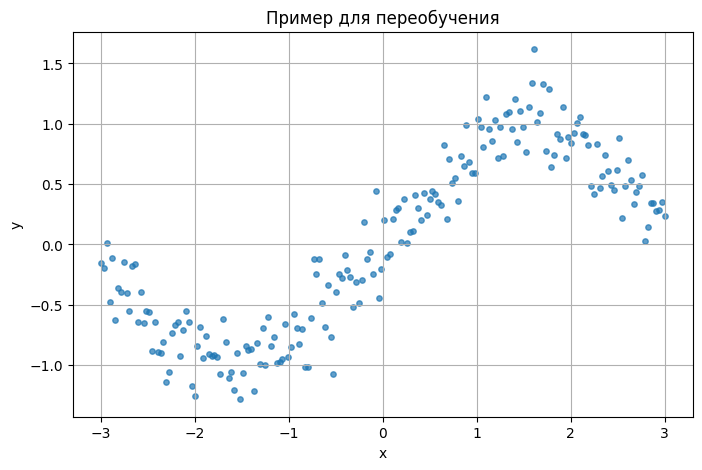

In [50]:
plt.figure(figsize=(8, 5))
plt.scatter(X_toy, y_toy, s=15, alpha=0.7)
plt.title("Пример для переобучения")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [51]:
#8.2 Создаём полиномиальные признаки степени 10 для базовых признаков 
from sklearn.preprocessing import PolynomialFeatures

basic_features = ["bathrooms", "bedrooms", "interest_level"]
X_poly_base = train_df[basic_features] # матрица из новых признаков

poly = PolynomialFeatures(degree=10, include_bias=False) # Создаём полином
X_poly = poly.fit_transform(X_poly_base) # Преоброзуем данные

print("Исходное количество признаков:", len(basic_features))
print("Количество признаков после PolynomialFeatures:", X_poly.shape[1])

Исходное количество признаков: 3
Количество признаков после PolynomialFeatures: 285


In [52]:
poly_feature_names = poly.get_feature_names_out(basic_features)
print("Имена новых признаков:")
print(poly_feature_names[:20])

Имена новых признаков:
['bathrooms' 'bedrooms' 'interest_level' 'bathrooms^2'
 'bathrooms bedrooms' 'bathrooms interest_level' 'bedrooms^2'
 'bedrooms interest_level' 'interest_level^2' 'bathrooms^3'
 'bathrooms^2 bedrooms' 'bathrooms^2 interest_level'
 'bathrooms bedrooms^2' 'bathrooms bedrooms interest_level'
 'bathrooms interest_level^2' 'bedrooms^3' 'bedrooms^2 interest_level'
 'bedrooms interest_level^2' 'interest_level^3' 'bathrooms^4']


In [53]:
# 8.3 Обучение моделей на полиномиальных признаках
# Для устойчивости сначала стандартизуем полиномиальные признаки

from sklearn.preprocessing import StandardScaler

poly_scaler = StandardScaler()
X_poly_scaled = poly_scaler.fit_transform(X_poly)

In [54]:
poly_linear_model = MyLinearRegressionSGD(learning_rate=1e-6, n_epochs=20)
poly_linear_model.fit(X_poly_scaled, y_train)
y_pred_poly_linear = poly_linear_model.predict(X_poly_scaled)

In [55]:
poly_ridge_model = MyRidgeSGD(learning_rate=1e-6, n_epochs=20, alpha=0.01)
poly_ridge_model.fit(X_poly_scaled, y_train)
y_pred_poly_ridge = poly_ridge_model.predict(X_poly_scaled)

In [56]:
poly_lasso_model = MyLassoSGD(learning_rate=1e-6, n_epochs=20, alpha=0.01)
poly_lasso_model.fit(X_poly_scaled, y_train)
y_pred_poly_lasso = poly_lasso_model.predict(X_poly_scaled)

In [57]:
poly_elastic_model = MyElasticNetSGD(learning_rate=1e-6, n_epochs=20, alpha=0.01, l1_ratio=0.5)
poly_elastic_model.fit(X_poly_scaled, y_train)
y_pred_poly_elastic = poly_elastic_model.predict(X_poly_scaled)

In [58]:
print("Linear Regression + PolynomialFeatures")
print("MAE:", round(mae_custom(y_train, y_pred_poly_linear), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_poly_linear), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_poly_linear), 4))

print("\nRidge + PolynomialFeatures")
print("MAE:", round(mae_custom(y_train, y_pred_poly_ridge), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_poly_ridge), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_poly_ridge), 4))

print("\nLasso + PolynomialFeatures")
print("MAE:", round(mae_custom(y_train, y_pred_poly_lasso), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_poly_lasso), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_poly_lasso), 4))

print("\nElasticNet + PolynomialFeatures")
print("MAE:", round(mae_custom(y_train, y_pred_poly_elastic), 4))
print("RMSE:", round(rmse_custom(y_train, y_pred_poly_elastic), 4))
print("R2:", round(r2_score_custom(y_train, y_pred_poly_elastic), 4))

Linear Regression + PolynomialFeatures
MAE: 0.0646
RMSE: 0.1081
R2: 0.9702

Ridge + PolynomialFeatures
MAE: 0.0651
RMSE: 0.1082
R2: 0.9701

Lasso + PolynomialFeatures
MAE: 0.0677
RMSE: 0.1142
R2: 0.9667

ElasticNet + PolynomialFeatures
MAE: 0.0656
RMSE: 0.1093
R2: 0.9695


In [59]:
# 8.4 Сохраняем результаты полиномиальных моделей в таблицы

mae_table_poly = pd.DataFrame({
    "model": [
        "Linear_custom_Polynomial",
        "Ridge_custom_Polynomial",
        "Lasso_custom_Polynomial",
        "ElasticNet_custom_Polynomial"
    ],
    "train": [
        mae_custom(y_train, y_pred_poly_linear),
        mae_custom(y_train, y_pred_poly_ridge),
        mae_custom(y_train, y_pred_poly_lasso),
        mae_custom(y_train, y_pred_poly_elastic)
    ],
    "test": [np.nan, np.nan, np.nan, np.nan]
})

rmse_table_poly = pd.DataFrame({
    "model": [
        "Linear_custom_Polynomial",
        "Ridge_custom_Polynomial",
        "Lasso_custom_Polynomial",
        "ElasticNet_custom_Polynomial"
    ],
    "train": [
        rmse_custom(y_train, y_pred_poly_linear),
        rmse_custom(y_train, y_pred_poly_ridge),
        rmse_custom(y_train, y_pred_poly_lasso),
        rmse_custom(y_train, y_pred_poly_elastic)
    ],
    "test": [np.nan, np.nan, np.nan, np.nan]
})

r2_table_poly = pd.DataFrame({
    "model": [
        "Linear_custom_Polynomial",
        "Ridge_custom_Polynomial",
        "Lasso_custom_Polynomial",
        "ElasticNet_custom_Polynomial"
    ],
    "train": [
        r2_score_custom(y_train, y_pred_poly_linear),
        r2_score_custom(y_train, y_pred_poly_ridge),
        r2_score_custom(y_train, y_pred_poly_lasso),
        r2_score_custom(y_train, y_pred_poly_elastic)
    ],
    "test": [np.nan, np.nan, np.nan, np.nan]
})

In [60]:
print("Результаты метрик качества MAE")
display(mae_table_poly)
print("Результаты метрик качества RMSE")
display(rmse_table_poly)
print("Результаты метрик качества R2")
display(r2_table_poly)

Результаты метрик качества MAE


,model,train,test
0,Linear_custom_Polynomial,0.064569,NaN
1,Ridge_custom_Polynomial,0.065139,NaN
2,Lasso_custom_Polynomial,0.067658,NaN
3,ElasticNet_custom_Polynomial,0.065572,NaN


Результаты метрик качества RMSE


,model,train,test
0,Linear_custom_Polynomial,0.108067,NaN
1,Ridge_custom_Polynomial,0.108216,NaN
2,Lasso_custom_Polynomial,0.114228,NaN
3,ElasticNet_custom_Polynomial,0.109272,NaN


Результаты метрик качества R2


,model,train,test
0,Linear_custom_Polynomial,0.970201,NaN
1,Ridge_custom_Polynomial,0.970119,NaN
2,Lasso_custom_Polynomial,0.966707,NaN
3,ElasticNet_custom_Polynomial,0.969533,NaN


## 8.5. Анализ результатов и выбор лучшей модели

После построения полиномиальных признаков степени 10 качество моделей резко выросло по сравнению с обычными признаками. Это видно по значениям `R2`, которые для всех моделей стали близки к 1. Значит, полиномиальные признаки позволили модели намного лучше аппроксимировать зависимость в данных.

Лучший результат показала обычная полиномиальная линейная регрессия, так как у нее самое высокое значение и одно из самых низких значений ошибок. Очень близкий результат показала модель `Ridge`, что говорит о хорошем балансе между качеством и устойчивостью. Модели `Lasso` и `ElasticNet` также показали высокое качество, но немного уступили по метрикам.

Таким образом, на данном этапе лучшей моделью по качеству можно считать `Linear Regression` на полиномиальных признаках. Однако с точки зрения устойчивости к переобучению более надежным выбором может быть `Ridge`, так как регуляризация ограничивает рост коэффициентов и делает модель более стабильной.

## 9. Наивные модели

Наивная модель — это очень простая базовая модель, которая делает предсказания без сложного обучения и без учета зависимостей между признаками и целевой переменной.

В задачах регрессии она обычно предсказывает среднее или медиану целевой переменной для всех объектов.

Ее задача не в том, чтобы показать лучшее качество, а в том, чтобы служить отправной точкой для сравнения. Если сложная модель не лучше наивной, значит она либо плохо настроена, либо не извлекает полезную информацию из данных.

В задачах регрессии наивная модель часто:
- всегда предсказывает среднее значение целевой переменной
- или всегда предсказывает медиану целевой переменной

Наивная модель нужна для того, чтобы понять, дает ли более сложная модель реальное улучшение качества.

Если метрики из линейной регрессия, Ridge, Lasso, ElasticNet показывают лучшие значения, чем наивная модель, значит они действительно извлекают полезную информацию из признаков.

In [61]:
# 9.1 Наивные модели: mean и median

mean_value = y_train.mean()
median_value = y_train.median()

y_pred_mean = np.full(len(y_train), mean_value)
y_pred_median = np.full(len(y_train), median_value)

In [62]:
# Считаем метрики
mae_mean = mae_custom(y_train, y_pred_mean)
rmse_mean = rmse_custom(y_train, y_pred_mean)
r2_mean = r2_score_custom(y_train, y_pred_mean)

mae_median = mae_custom(y_train, y_pred_median)
rmse_median = rmse_custom(y_train, y_pred_median)
r2_median = r2_score_custom(y_train, y_pred_median)

In [63]:
# Посмотрим результат
print("Naive Mean")
print("MAE:", round(mae_mean, 4))
print("RMSE:", round(rmse_mean, 4))
print("R2:", round(r2_mean, 4))

print("\nNaive Median")
print("MAE:", round(mae_median, 4))
print("RMSE:", round(rmse_median, 4))
print("R2:", round(r2_median, 4))

Naive Mean
MAE: 0.5323
RMSE: 0.626
R2: 0.0

Naive Median
MAE: 0.3831
RMSE: 0.7339
R2: -0.3745


In [64]:
# Добавим в итоговые таблицы
naive_mae_table = pd.DataFrame({
    "model": ["NaiveMean", "NaiveMedian"],
    "train": [mae_mean, mae_median],
    "test": [np.nan, np.nan]
})

naive_rmse_table = pd.DataFrame({
    "model": ["NaiveMean", "NaiveMedian"],
    "train": [rmse_mean, rmse_median],
    "test": [np.nan, np.nan]
})

naive_r2_table = pd.DataFrame({
    "model": ["NaiveMean", "NaiveMedian"],
    "train": [r2_mean, r2_median],
    "test": [np.nan, np.nan]
})

## 10. Сравнение результатов

In [67]:
# 10.1 Выведите итоговые таблицы
final_mae_table = pd.concat(
    [mae_table, mae_table_reg, mae_table_scaled, mae_table_poly, naive_mae_table],
    ignore_index=True
)

final_rmse_table = pd.concat(
    [rmse_table, rmse_table_reg, rmse_table_scaled, rmse_table_poly, naive_rmse_table],
    ignore_index=True
)

final_r2_table = pd.concat(
    [r2_table, r2_table_reg, r2_table_scaled, r2_table_poly, naive_r2_table],
    ignore_index=True
)

In [68]:
print("Final MAE table")
display(final_mae_table)

print("Final RMSE table")
display(final_rmse_table)

print("Final R2 table")
display(final_r2_table)

Final MAE table


,model,train,test
0,MyLinearRegressionSGD,0.503213,NaN
1,LinearRegression_sklearn,0.491468,NaN
2,MyRidgeSGD,0.495741,NaN
3,Ridge_sklearn,0.491468,NaN
4,MyLassoSGD,0.492921,NaN
5,Lasso_sklearn,0.508838,NaN
6,MyElasticNetSGD,0.506300,NaN
7,ElasticNet_sklearn,0.501531,NaN
8,Linear_custom_MinMax,0.492725,NaN
9,Ridge_custom_MinMax,0.492462,NaN


Final RMSE table


,model,train,test
0,MyLinearRegressionSGD,0.604441,NaN
1,LinearRegression_sklearn,0.603125,NaN
2,MyRidgeSGD,0.603431,NaN
3,Ridge_sklearn,0.603125,NaN
4,MyLassoSGD,0.605660,NaN
5,Lasso_sklearn,0.609245,NaN
6,MyElasticNetSGD,0.604823,NaN
7,ElasticNet_sklearn,0.605737,NaN
8,Linear_custom_MinMax,0.603349,NaN
9,Ridge_custom_MinMax,0.605535,NaN


Final R2 table


,model,train,test
0,MyLinearRegressionSGD,0.067779,NaN
1,LinearRegression_sklearn,0.071833,NaN
2,MyRidgeSGD,0.070891,NaN
3,Ridge_sklearn,0.071833,NaN
4,MyLassoSGD,0.064013,NaN
5,Lasso_sklearn,0.052902,NaN
6,MyElasticNetSGD,0.066598,NaN
7,ElasticNet_sklearn,0.063775,NaN
8,Linear_custom_MinMax,0.071145,NaN
9,Ridge_custom_MinMax,0.064400,NaN


### 10.2-3. Какая модель лучшая? Какая модель стабильнее

Если ориентироваться только на метрики на обучающей выборке, наилучший результат показала `Linear_custom_Polynomial`, так как у нее самое высокое значение `R2` и самые низкие ошибки среди рассмотренных моделей.

Однако этот результат нужно интерпретировать осторожно. Полиномиальные признаки степени 10 сильно увеличивают сложность модели, а значение `R2`, близкое к 1 на train, может свидетельствовать о переобучении. Это означает, что модель очень хорошо подстроилась под обучающие данные.

Поэтому формально лучшая модель по train-метрикам — `Linear_custom_Polynomial`, но с точки зрения устойчивости и борьбы с переобучением более надежным выбором может быть `Ridge_custom_Polynomial`, поскольку регуляризация ограничивает рост коэффициентов и делает модель стабильнее.